## Imports

In [1]:
import scipy.io
import numpy as np
from sklearn import linear_model 
from scipy import linalg
from sklearn import preprocessing as preproc # load preprocessing function
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
from scipy.stats import linregress
from sklearn.model_selection import KFold
from statsmodels.sandbox.stats.multicomp import multipletests 
import warnings # to silence convergence warnings

# seaborn can be used to "prettify" default matplotlib plots by importing and setting as default
import seaborn as sns
sns.set() # Set searborn as default

## Load dataset

In [2]:
mat = scipy.io.loadmat('sand.mat')

X = mat['X']
y = mat['Y']

[n,p] = X.shape

### 2 Find an elastic net solution for the sand data, with suitable choices of regression parameters using cross validation.

>(a) Use the coordinate descent algorithm.

>>(i) Python: Use Python’s `linear_model.ElasticNet`.

>(b) Investigate how different values of α affects the number of nonzero parameters in the coordinate descent algorithms.
  
>(c) What are the pros and cons of the coordinate descent algorithm compared to using LARS?

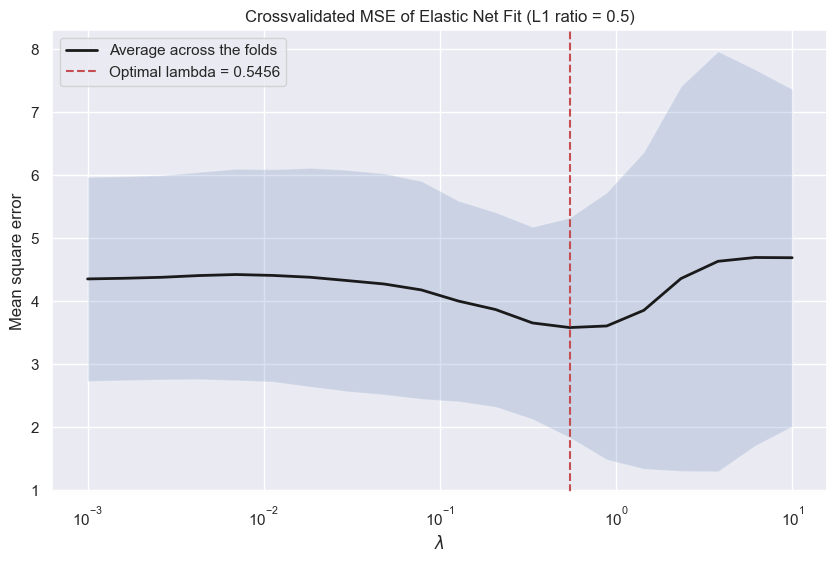

Optimal lambda: 0.545559
Number of nonzero coefficients: 47


In [3]:
# set up a range of lambdas and an alpha value
alpha = 0.5  # Ridge-Lasso balance parameter
lambdas = np.logspace(-3, 1, num=20)

with warnings.catch_warnings(): # done to disable all the convergence warnings from elastic net
    warnings.simplefilter("ignore")

    # Use ElasticNetCV for automatic cross-validation
    # alpha parameter in scikit-learn is the mixing parameter (L1 ratio)
    # l1_ratio=0.5 means 50% L1 (Lasso) and 50% L2 (Ridge)
    model = linear_model.ElasticNetCV(
        l1_ratio=alpha, 
        alphas=lambdas,  # These are the lambda values to try
        cv=5,             # 5-fold cross-validation
        max_iter=10000
    )
    model.fit(X, y)
    
plt.figure(figsize=(10, 6))
plt.semilogx(model.alphas_, model.mse_path_.mean(axis=-1), 'k', label='Average across the folds', linewidth=2)
plt.fill_between(model.alphas_, 
                 model.mse_path_.mean(axis=-1) - model.mse_path_.std(axis=-1),
                 model.mse_path_.mean(axis=-1) + model.mse_path_.std(axis=-1),
                 alpha=0.2)
plt.axvline(model.alpha_, color='r', linestyle='--', label=f'Optimal lambda = {model.alpha_:.4f}')
plt.xlabel(r'$\lambda$')
plt.ylabel('Mean square error')
plt.title(f'Crossvalidated MSE of Elastic Net Fit (L1 ratio = {alpha})')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal lambda: {model.alpha_:.6f}")
print(f"Number of nonzero coefficients: {np.sum(model.coef_ != 0)}")

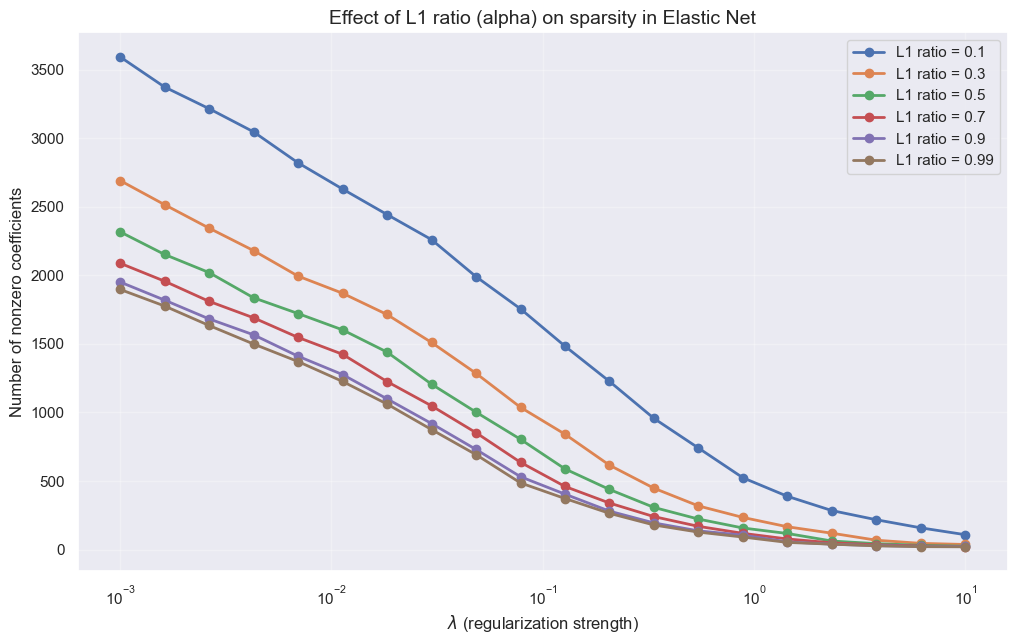

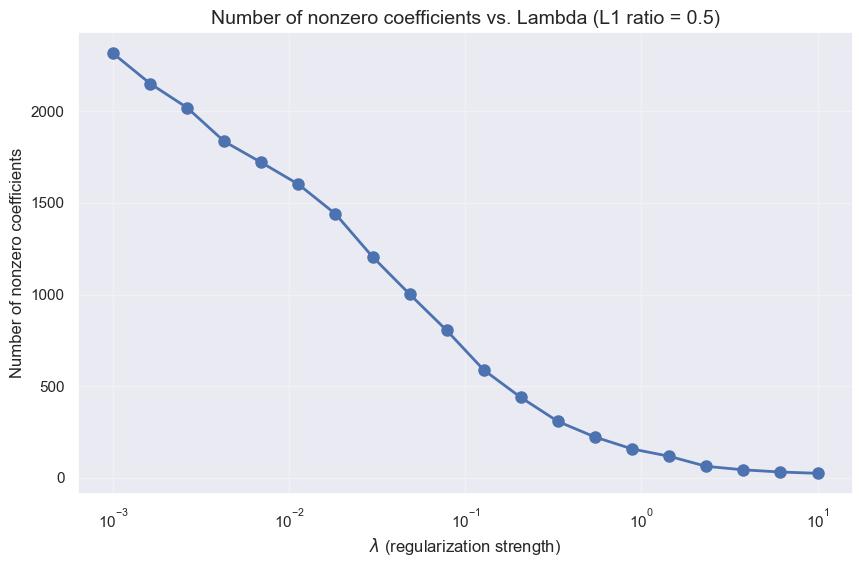

In [4]:
# To investigate how different values of alpha (L1 ratio) affect the number of nonzero parameters
# we implement cross-validation ourselves across multiple alpha values

CV = 5
kf = KFold(n_splits=CV, shuffle=True, random_state=42)

alphas_to_test = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]  # Different L1 ratio values
results = {}

for alpha_test in alphas_to_test:
    coefs = np.zeros((CV, len(lambdas), p))
    
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        # Get training data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        for j, lambda_ in enumerate(lambdas):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                # Run the ElasticNet model with coordinate descent algorithm
                # (which is the default solver in sklearn)
                model = linear_model.ElasticNet(
                    alpha=lambda_,           # Regularization strength
                    l1_ratio=alpha_test,     # L1 ratio (0=Ridge, 1=Lasso)
                    max_iter=10000,
                    random_state=42
                )
                model.fit(X_train, y_train)
                coefs[i, j, :] = model.coef_
    
    # Calculate the number of nonzero coefficients across folds and lambdas
    num_nonzero = np.sum(coefs != 0, axis=(0, 2))  # Sum across folds and features
    results[alpha_test] = num_nonzero

# Plot how the number of nonzero parameters changes with lambda for different alphas
plt.figure(figsize=(12, 7))
for alpha_test in alphas_to_test:
    plt.semilogx(lambdas, results[alpha_test], marker='o', label=f'L1 ratio = {alpha_test}', linewidth=2)

plt.xlabel(r'$\lambda$ (regularization strength)', fontsize=12)
plt.ylabel('Number of nonzero coefficients', fontsize=12)
plt.title('Effect of L1 ratio (alpha) on sparsity in Elastic Net', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate trace (sum of absolute coefficients) for the original alpha=0.5
alpha = 0.5
coefs = np.zeros((CV, len(lambdas), p))

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    for j, lambda_ in enumerate(lambdas):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            model = linear_model.ElasticNet(
                alpha=lambda_,
                l1_ratio=alpha,
                max_iter=10000,
                random_state=42
            )
            model.fit(X_train, y_train)
            coefs[i, j, :] = model.coef_

# Count nonzero coefficients across CV folds
num_nonzero = np.sum(coefs != 0, axis=(0, 2))

plt.figure(figsize=(10, 6))
plt.semilogx(lambdas, num_nonzero, marker='o', linewidth=2, markersize=8)
plt.xlabel(r'$\lambda$ (regularization strength)', fontsize=12)
plt.ylabel('Number of nonzero coefficients', fontsize=12)
plt.title(f'Number of nonzero coefficients vs. Lambda (L1 ratio = {alpha})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## (c) Coordinate Descent vs. LARS Algorithm

### Coordinate Descent Algorithm:

**Pros:**
- **Efficient for high-dimensional data**: Scales well with the number of features (p)
- **Simple implementation**: Easy to understand and parallelize
- **Handles elastic net naturally**: Seamlessly incorporates both L1 and L2 penalties
- **Fast convergence**: Often converges quickly in practice
- **Flexibility**: Works with various loss functions (not just quadratic)
- **Widely available**: Implemented in major libraries (scikit-learn, etc.)

**Cons:**
- **Does not produce the full solution path efficiently**: Must re-fit for each λ value
- **Requires specifying stopping criteria**: Convergence can be sensitive to tolerance parameters
- **Can get stuck in local minima**: Non-convex optimization in some cases
- **Slower for very sparse solutions**: Compared to LARS in certain scenarios

### LARS (Least Angle Regression) Algorithm:

**Pros:**
- **Produces the entire regularization path efficiently**: Computes solutions for all λ values simultaneously
- **Interpretable**: Can visualize variable inclusion order
- **Lower computational cost for full path**: Single pass produces all solutions
- **Exact solution**: No iterative approximations needed

**Cons:**
- **Does not directly handle elastic net**: Primarily designed for LASSO (L1 only)
- **Less scalable**: Computational complexity grows with the number of samples (n)
- **Memory intensive**: Stores the solution path for all λ values
- **Performance degrades with p >> n**: Can be slow when features >> samples (though still useful)
- **Sensitive to collinearity**: Can have numerical stability issues with highly correlated features

### Summary:
For this problem, **coordinate descent is preferred** because:
1. We need to handle elastic net (mixed L1 & L2 penalty), which LARS doesn't natively support
2. The implementation is straightforward with ElasticNetCV
3. It provides good control through the l1_ratio parameter
4. Cross-validation with coordinate descent is computationally tractable